# Beispiel 11.5: Anfahrverhalten eines katalytischen Rohrreaktors

Bearbeitet von Marcel Broocks 

Dieses Beispiel befindet sich im Lehrbuch auf der Seite 155 und behandelt das Anfahrverhalten eines katalytischen Rohrreaktors. Im Reaktor, der einen Durchmesser von $0{,}025 \, \mathrm{m}$ und eine Länge von $5 \, \mathrm{m}$ hat, läuft eine stark exotherme Reaktion ab, sodass sich eine adiabatische Temperaturerhöhung von $\Delta T_{\mathrm{ad}} = 500 \, \mathrm{K}$ ergibt. Dieser Wert folgt aus der Zulaufkonzentration $c_ {\mathrm{1,e}} = 1 \, \mathrm{mol \, m^{-3}}$, der Reaktionsenthalpie $\Delta_{\mathrm{R}}H = -350 \, \mathrm{kJ \, mol^{-1}}$ und der volumenspezifischen Wärmekapazität der gasförmigen Reaktionsmischung $\rho_{\mathrm{G}} \, c_{\mathrm{p,G}} = 0{,}7 \, \mathrm{kJ \, m^{-3} \, K^{-1}}$. Weiterhin ist die Strömungsgeschwindigkeit mit $u = 2 \, \mathrm{m \, s^{-1}}$ angegeben und die Koeffizienten der Kinetik 1. Ordnung betragen $E_{\mathrm{A}} = 81{,}5 \, \mathrm{kJ \, mol^{-1}}$ und $k_0 = 2{,}7 \cdot 10^6 \, {\mathrm{s}}^{-1}$. Der Wärmedurchgangskoeffizient beträgt $100 \, \mathrm{W \, m^{-2} \, K^{-1}}$, zudem sind die Zulauf- und Kühlmitteltemperatur identisch zur Anfangstemperatur und weisen einen Wert von $673 \, \mathrm{K}$ auf.  <br>
Ziel dieses Beispiels ist die Darstellung des zeitlichen Verlaufes der Reaktortemperatur und des Umsatzgrades in Abhängigkeit von der Reaktorlänge, wobei der stationäre Zustand nach etwa 16 min erreicht wird.  

# Importieren der benötigten Pakete
Bevor mit der Berechnung gestartet werden kann, müssen zur Bearbeitung des Beispiels folgende Pakete importiert werden:

- numpy
    - Zur Durchführung von numerischen Rechenoperationen und zum Arbeiten mit Arrays
    - Informationen unter https://numpy.org/doc/stable/reference/routines.array-creation.html
- matplotlib
    - Zum Erstellen von Grafiken
    - Informationen unter https://matplotlib.org/stable/tutorials/introductory/index.html
- scipy
    - Zur Durchführung wissenschaftlicher Rechnungen (hier zur Lösung von ODEs mithilfe von LSODA)
    - Informationen unter https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

Diese Pakete werden nun importiert und alle gegebenen Größen implementiert.

In [1]:
# Importieren der benötigten Pakete 
import numpy as np                           # numerische Rechenoperationen
import matplotlib.pyplot as plt              # Darstellung von Diagrammen 
from scipy.integrate import solve_ivp        # Lösen von DGLs
from matplotlib.ticker import FuncFormatter  # Achsenbeschriftung 

# Implementierung der gegebenen Größen
d_R = 0.025                                  # Reaktordurchmesser / m
L_R = 5                                      # Reaktorlänge / m
Delta_T_ad = 500                             # adiabatische Temperaturdifferenz / K 
c_1e = 1                                     # Zulaufkonzentration / mol m^-3
Delta_RH = -350e3                            # Reaktionsenthalpie / J mol^-1
rho_cp_G = 0.7e3                             # volumenspezifische Wärmekapazität des Gases / J m^-3 K^-1
u = 2                                        # Strömungschwindigkeit / m s^-1
E_A = 81.5e3                                 # Aktivierungsenergie / J mol^-1
k_0 = 2.7e6                                  # Frequenzfaktor / s^-1
R = 8.314                                    # universelle Gaskonstante / J mol^-1 K^-1
h_W = 100                                    # Wärmedurchgangskoeffizient / W m^-2 K^-1
T_e = T_K = 673                              # Zulauf- und Kühlmitteltemperatur / K

Zum Lösen des Systems wird die Material- und Energiebilanz für den Rohrreaktor herangezogen (Gleichungen (11.1a) und (11.1b)). Es wird nur eine ablaufende Reaktion 1. Ordnung mit dem stöchiometrischen Koeffizienten $\nu_1 = -1$ betrachtet, wodurch die Summe im Reaktionsterm entfällt. Zu Beginn der Reaktion sei der Reaktor mit Inertgas gefüllt. Zu beachten ist, im Akkumulationsterm der Energiebilanz, eine durch den festen Katalysator dominierte effektive volumenspezifische Wärmekapazität $\rho_{\mathrm{eff}} \, c_{\mathrm{p,eff}}$ von $1440 \, \mathrm{kJ \, m^{−3} \, K^{−1}}$. Insgesamt vereinfachen sich die Gleichungen damit zu:
$$
\begin{aligned}
\dfrac{\partial c_i}{\partial t}
&= -u \, \dfrac{\partial c_i}{\partial z}
  + \sum_j \nu_{i,j} \, r_j
\quad \longrightarrow \quad
\dfrac{\partial c_1}{\partial t}
= -u \, \dfrac{\partial c_1}{\partial z} - r
\\[1em]
\rho \, c_{\mathrm{p}} \, \dfrac{\partial T}{\partial t}
&= -\dfrac{4}{\pi} \, \dfrac{\dot{n} \, c_{\mathrm{p}}}{d_{\mathrm{R}}^2}
   \, \dfrac{\partial T}{\partial z}
   - \sum_j r_j \, \Delta_{\mathrm{R}}H_j
   - h_{\mathrm{W}} \, \dfrac{4}{d_{\mathrm{R}}}
     \, (T - \overline{T}_{\mathrm{K}})
\\
&\longrightarrow\;
\rho_{\mathrm{eff}} \, c_{\mathrm{p,eff}} \, \dfrac{\partial T}{\partial t}
= -u \, \rho_{\mathrm{G}} \, c_{\mathrm{p,G}} \, \dfrac{\partial T}{\partial z}
  - r \, \Delta_{\mathrm{R}}H
  - h_{\mathrm{W}} \, \dfrac{4}{d_{\mathrm{R}}}
    \, (T - \overline{T}_{\mathrm{K}})
\end{aligned}
$$

mit den Anfangsbedingungen <br> <br>
$$ 
\quad \quad \quad c_1(t = 0) = c_{1,0} \quad \mathrm{und} \quad T(t = 0) = T_0
$$ <br> <br>
und den Randbedingungen <br> <br>
$$
\quad \quad \quad c_1(z = 0) = c_{\mathrm{1,e}} \quad \mathrm{und} \quad T(z = 0) = T_{\mathrm{e}}.
$$

Im nächsten Schritt wird die effektive volumenspezifische Wärmekapazität $\rho_{\mathrm{eff}} \, c_{\mathrm{p,eff}}$ definiert. Anschließend erfolgt die räumliche Diskretisierung der Rohrlänge $L_{\mathrm{R}}$ in $N$ äquidistante Stützstellen
$$
z_0, z_1, \dots, z_{N-1}
\qquad \text{mit} \qquad
\Delta z = \frac{L_{\mathrm{R}}}{N-1}.
$$

Die kontinuierlichen Größen $c_1(z,t)$ und $T(z,t)$ werden dadurch durch zeitabhängige diskrete Werte $c_{1,i}(t)$ bzw. $T_i(t)$ an den Gitterpunkten $z_i$ beschrieben.

Zur Approximation der räumlichen Ableitungen wird die **zentrale Finite-Differenzen-Methode** verwendet. Für innere Gitterpunkte $i = 1, \dots, N-2$ gilt:
$$
\left.\frac{\partial \phi}{\partial z}\right|_{z_i}
\approx
\frac{\phi_{i+1} - \phi_{i-1}}{2\,\Delta z},
$$

wobei $\phi$ stellvertretend für $c_1$ oder $T$ steht. An den Randpunkten werden einseitige Differenzen verwendet, um die Randbedingungen zu berücksichtigen.

Die Materialbilanz für die Komponente 1 ergibt sich nach der Diskretisierung zu:
$$
\frac{\mathrm{d} c_{1,i}}{\mathrm{d} t}
=
- u \,
\frac{c_{1,i+1} - c_{1,i-1}}{2\,\Delta z}
- r_i
\qquad (i = 1, \dots, N-2),
$$

wobei $r_i = k(T_i) \, c_{1,i}$ die Reaktionsgeschwindigkeit einer Reaktion 1. Ordnung darstellt. Analog folgt für die Energiebilanz:
$$
\rho_{\mathrm{eff}} \, c_{\mathrm{p,eff}}
\frac{\mathrm{d} T_i}{\mathrm{d} t}
=
- u \, \rho_{\mathrm{G}} \, c_{\mathrm{p,G}}
\frac{T_{i+1} - T_{i-1}}{2\,\Delta z}
- r_i \, \Delta_{\mathrm{R}}H
- h_{\mathrm{W}} \, \frac{4}{d_{\mathrm{R}}}
\left(T_i - \overline{T}_{\mathrm{K}}\right).
$$

Durch die räumliche Diskretisierung wird das ursprüngliche System von partiellen Differentialgleichungen **(PDEs)** in ein großes, gekoppeltes System von gewöhnlichen Differentialgleichungen **(ODEs)** überführt:

- $N$ ODEs für die Materialbilanz
- $N$ ODEs für die Energiebilanz

Dieses ODE-System kann anschließend mit geeigneten zeitabhängigen Integrationsverfahren numerisch gelöst werden.

In [2]:
rho_cp_eff = 1440e3                          # effektive volumenspezifische Wärmekapazität / J m^-3 K^-1

# Diskretisierung
N = 200
z = np.linspace(0, L_R, N)
dz = z[1]-z[0]

# zentrale Finite-Differenzen
def CFD(var, dz):
    d_var = np.zeros_like(var)
    # für innere Punkte
    d_var[1:-1] = (var[2:] - var[:-2]) / (2 * dz)
    # für Randpunkte
    d_var[0] = (var[1] - var[0]) / dz
    d_var[-1] = (var[-1] - var[-2]) / dz
    return d_var

Für die Reaktionsgeschwindigkeitskonstante muss der Arrhenius-Ansatz nach Gleichung (5.7) berücksichtigt werden:
$$
k(T) = k_0 \, \exp\left(-\frac{E_{\mathrm{A}}}{R \, T}\right).
$$

In [3]:
def Arrhenius(c1, T):
    k = k_0 * np.exp(-E_A / (R * T))
    r = k * c1
    return r

Die jetzt vorliegenden ODEs können mithilfe von solve_ivp nach den Werten für Konzentration und Temperatur gelöst werden. Hierbei wird die Methode "LSODA" gewählt, da sie sich in diesem Fall besser als das Runge-Kutta-Verfahren eignet, weil das System bei großer Reaktionsgeschwindigkeit steif wird.

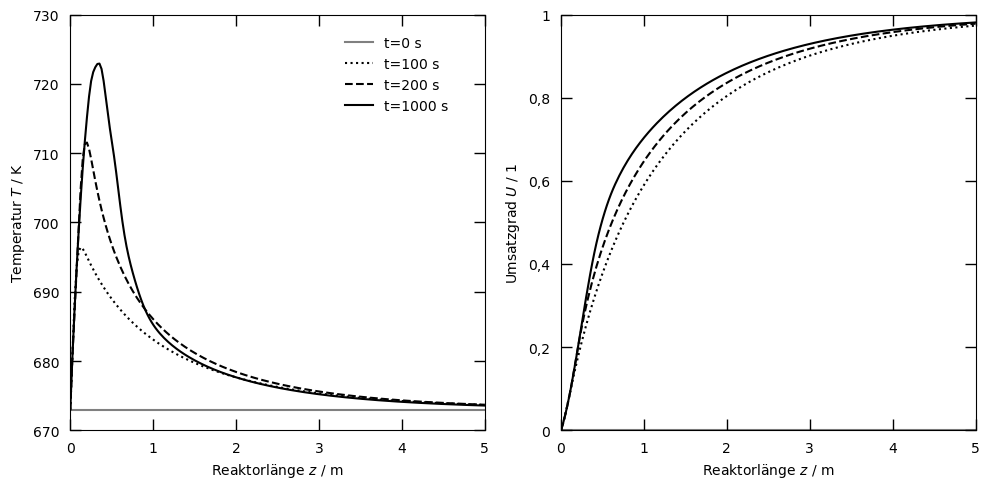

In [4]:
def ODEs(t, y):
    c1 = y[:N].copy()
    T = y[N:].copy()

    # Randbedingungen am Zulauf (Dirichlet)
    c1[0] = c_1e
    T[0] = T_e

    # Diskrete aus CFD-Methode
    dc1_dz = CFD(c1, dz)
    dT_dz = CFD(T, dz)

    # Reaktionsgeschwindigkeit nach Arrhenius
    r = Arrhenius(c1, T)

    # ODE-System - Gl. (11.1a und 11.1b)
    dc1_dt = -u * dc1_dz - r
    dT_dt = (-u * rho_cp_G * dT_dz - r * Delta_RH - h_W * 4 / d_R * (T - T_K)) / rho_cp_eff

    dc1_dt[0] = 0
    dT_dt[0] = 0

    return np.concatenate([dc1_dt, dT_dt])

# Anfangswerte: konstant über z
c1_0 = np.ones(N) * c_1e
T_0 = np.ones(N) * T_e

# alles zusammen als Startwert für den Integrator
y0 = np.concatenate([c1_0, T_0])

t_span = (0, 1000)

# Betrachtung der Verläufe zu den vier gegebenen Zeiten
t_eval = [0, 100, 200, 1000]

sol = solve_ivp(ODEs, t_span, y0, method='LSODA', t_eval=t_eval)

# Ergebnisse plotten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
color = ['grey', 'k', 'k', 'k']
lines = ['-', ':', '--', '-']
for i, t_point in enumerate(t_eval):
    c1_t = sol.y[:N, i]
    T_t = sol.y[N:, i]
    X_t = (c_1e - c1_t) / c_1e
    ax1.plot(z, T_t, label=f't={t_point} s', color=color[i], linestyle=lines[i])
    ax2.plot(z, X_t, label=f't={t_point} s', color=color[i], linestyle=lines[i])

# Achsenbeschriftung + Achsenskalierung
ax1.set_xlabel(r'Reaktorlänge $z$ / m')
ax1.set_ylabel(r'Temperatur $T$ / K')
ax1.set_xlim(0,5)
ax1.set_ylim(670,730)
ax2.set_xlabel(r'Reaktorlänge $z$ / m')
ax2.set_ylabel(r'Umsatzgrad $U$ / 1')
ax2.set_xlim(0,5)
ax2.set_ylim(0,1)
# Trennzeichen auf Achse (,)
axes = [ax1, ax2]
def format_with_comma(x, pos):
    if abs(x) < 0.2: return '0'
    elif abs(x) > 0.8: return '1'
    return f"{x:.1f}".replace('.', ',')
axes[1].yaxis.set_major_formatter(FuncFormatter(format_with_comma))
for ax in axes:
    ax.set_axisbelow(False)
    ax.tick_params(direction='in', top=True, right=True, length=8, width=1)
    ax.tick_params(axis='x', pad=8)
    ax.tick_params(axis='y', pad=8)
    ax.grid(False)
# Legende einfügen 
ax1.legend(loc=(0.65,0.75), frameon=False)
plt.tight_layout()
plt.show()

Die linke Abbildung zeigt, dass sich das Temperaturprofil über die Zeit ausprägt, aufgrunddessen steigt die mittlere Reaktionsgeschwindigkeit und damit auch der Umsatzgrad, vor allem im vorderen Bereich des Reaktors, an. 

**Erratum:** Im Lehrbuch wurde unter der Beschreibung des Beispiels 11.5 fälschlicherweise ein Reaktordurchmesser von $0{,}05 \, \mathrm{m}$ statt $0{,}025 \, \mathrm{m}$ angegeben. Zur Erstellung dieses Lösungsvorschlages wurde daher mit einem Reaktordurchmesser von $0{,}025 \, \mathrm{m}$ gerechnet, sodass die Verläufe denen im Lehrbuch entsprechen.